In [55]:
import numpy as np
import pandas as pd
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style(style='whitegrid')
sns.set_theme(rc={'figure.figsize':(11.7,8.27)})

In [56]:
df = pd.read_csv("../data/processed1/valid_selection.csv")

In [57]:
df.head()

,datetime,household_ID,branch,sub_type,date,time,consumption,Heating_Cooking,wave,Communication_IT,...,household_size,avg_age,max_age,num_children,num_adults,num_elderly,num_employed,avg_hours_home,dependency_ratio,employment_ratio
0,2023-12-09 05:49:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-09,05:49,2.5330,3.0,1.0,1.0,...,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0
1,2023-12-09 22:52:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-09,22:52,2.3300,3.0,1.0,1.0,...,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0
2,2023-12-10 05:49:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-10,05:49,1.4720,3.0,1.0,1.0,...,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0
3,2023-12-10 18:49:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-10,18:49,1.9111,3.0,1.0,1.0,...,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0
4,2023-12-11 05:48:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-11,05:48,2.3949,3.0,1.0,1.0,...,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0


In [58]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [59]:
df = df.sort_values('datetime')

In [60]:
df.set_index('datetime', inplace=True)

In [61]:
df.head()

,household_ID,branch,sub_type,date,time,consumption,Heating_Cooking,wave,Communication_IT,Mobility_Energy,...,household_size,avg_age,max_age,num_children,num_adults,num_elderly,num_employed,avg_hours_home,dependency_ratio,employment_ratio
datetime,,,,,,,,,,,,,,,,,,,,,
2023-12-09 01:05:00,ID0018,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-09,01:05,2.807,9.0,1.0,5.0,0.0,...,7.0,51.0,86.0,0.0,7.0,3.0,4.0,115.142857,0.428571,0.571429
2023-12-09 05:49:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-09,05:49,2.533,3.0,1.0,1.0,0.0,...,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.000000,1.000000,0.000000
2023-12-09 06:06:00,ID0018,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-09,06:06,1.770,9.0,1.0,5.0,0.0,...,7.0,51.0,86.0,0.0,7.0,3.0,4.0,115.142857,0.428571,0.571429
2023-12-09 22:52:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-09,22:52,2.330,3.0,1.0,1.0,0.0,...,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.000000,1.000000,0.000000
2023-12-09 23:01:00,ID0018,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-09,23:01,1.018,9.0,1.0,5.0,0.0,...,7.0,51.0,86.0,0.0,7.0,3.0,4.0,115.142857,0.428571,0.571429


<Axes: xlabel='datetime'>

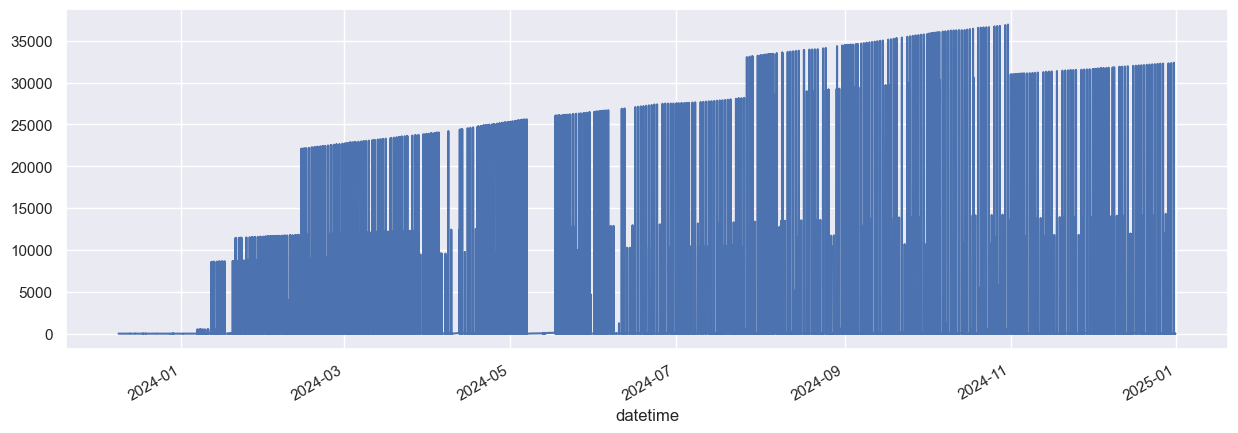

In [62]:
df['consumption'].plot(figsize=(15,5))

In [63]:
daily = df['consumption'].resample('D').sum()
monthly = df['consumption'].resample('ME').sum()

<Axes: title={'center': 'Daily Consumption'}, xlabel='datetime'>

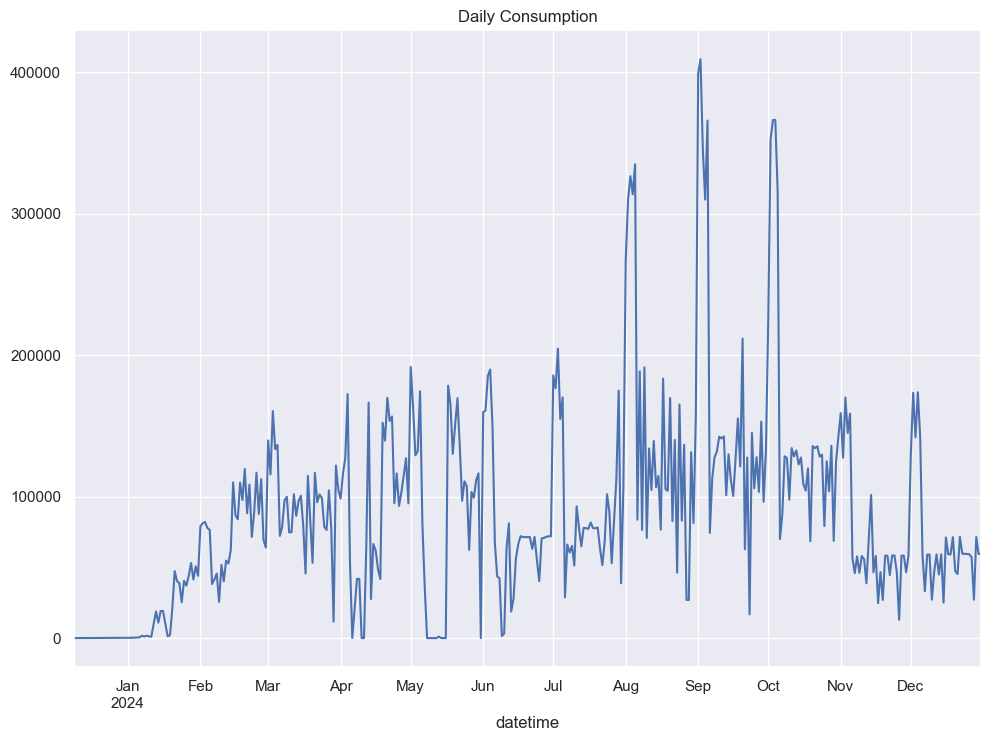

In [64]:
daily.plot(title='Daily Consumption')

<Axes: title={'center': 'Monthly Consumption'}, xlabel='datetime'>

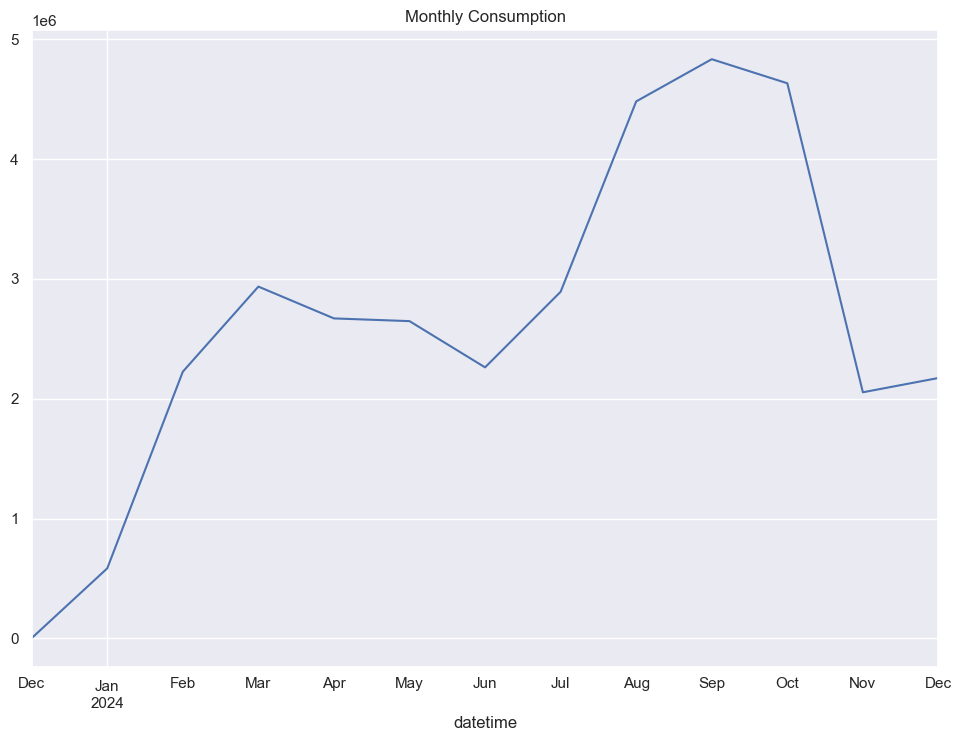

In [65]:
monthly.plot(title='Monthly Consumption')

In [66]:
df = df.reset_index()

In [67]:
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [68]:
df.set_index('datetime', inplace=True)

<Axes: xlabel='hour'>

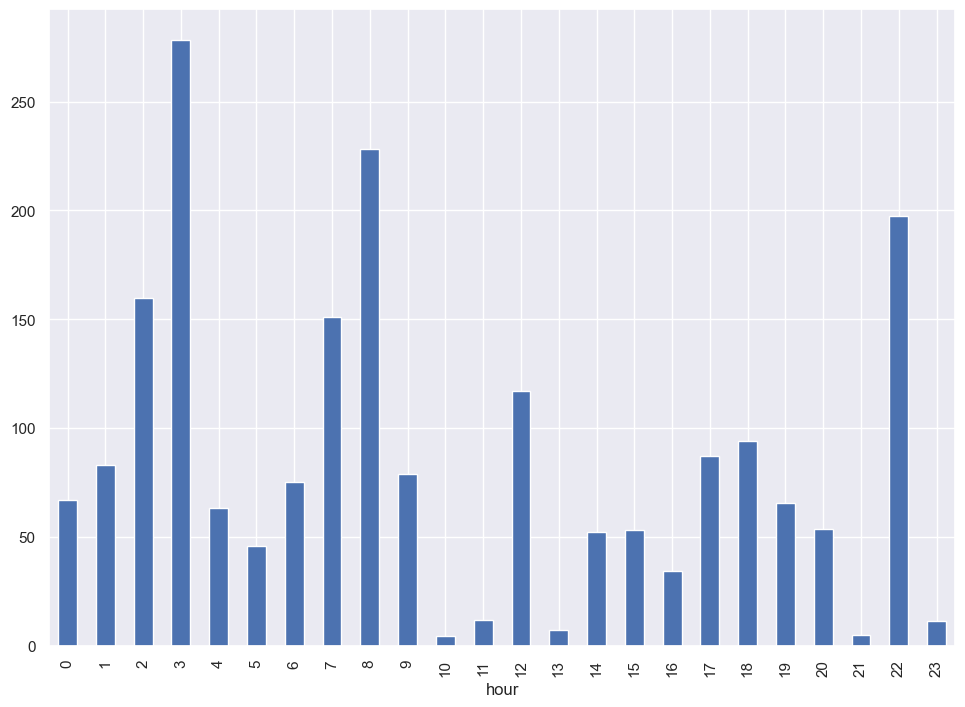

In [69]:
df.groupby('hour')['consumption'].mean().plot(kind='bar')

<Axes: xlabel='datetime'>

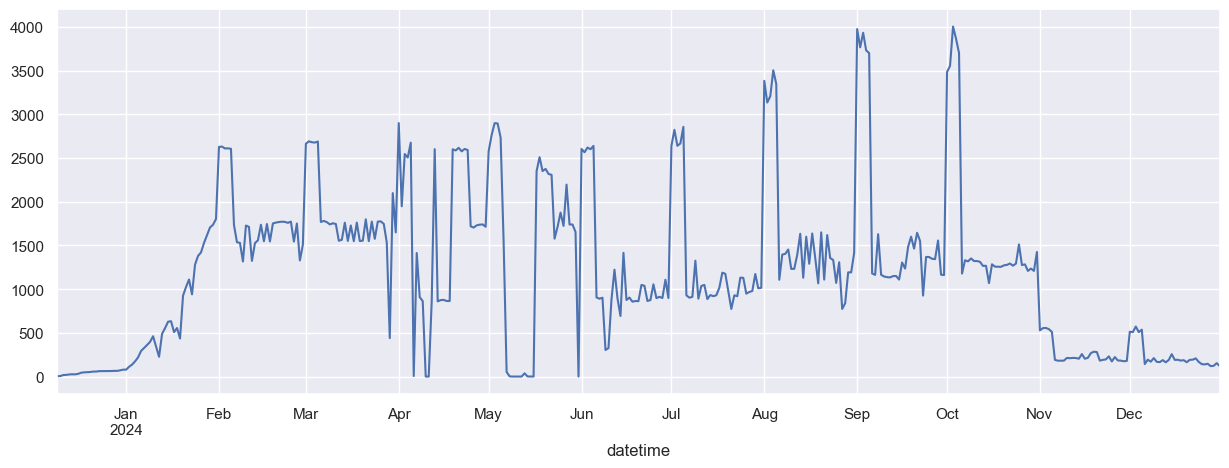

In [70]:
df['consumption'].resample('D').size().plot(figsize=(15,5))

<Axes: xlabel='datetime'>

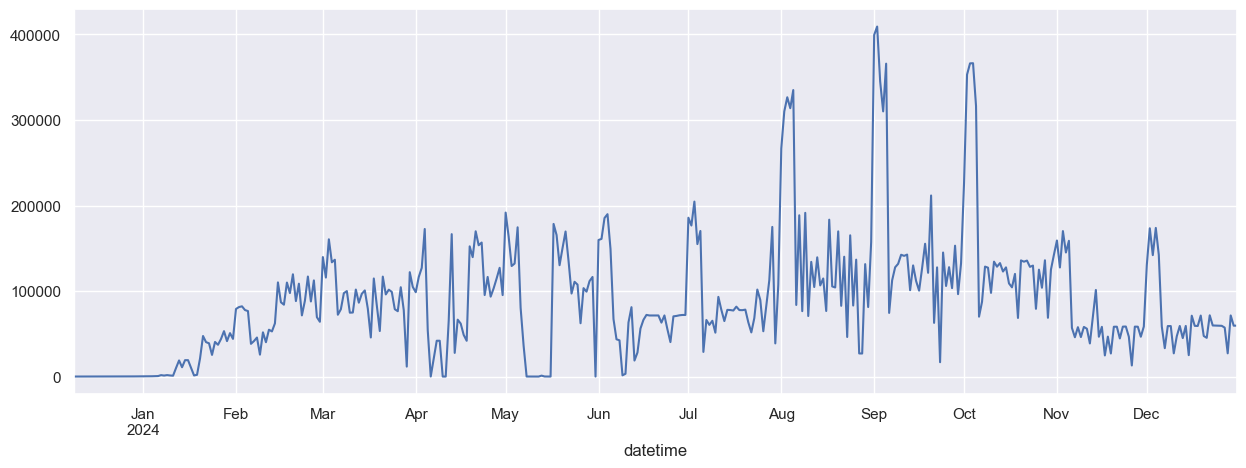

In [71]:
df['consumption'].resample('D').sum().plot(figsize=(15,5))

<Axes: xlabel='datetime'>

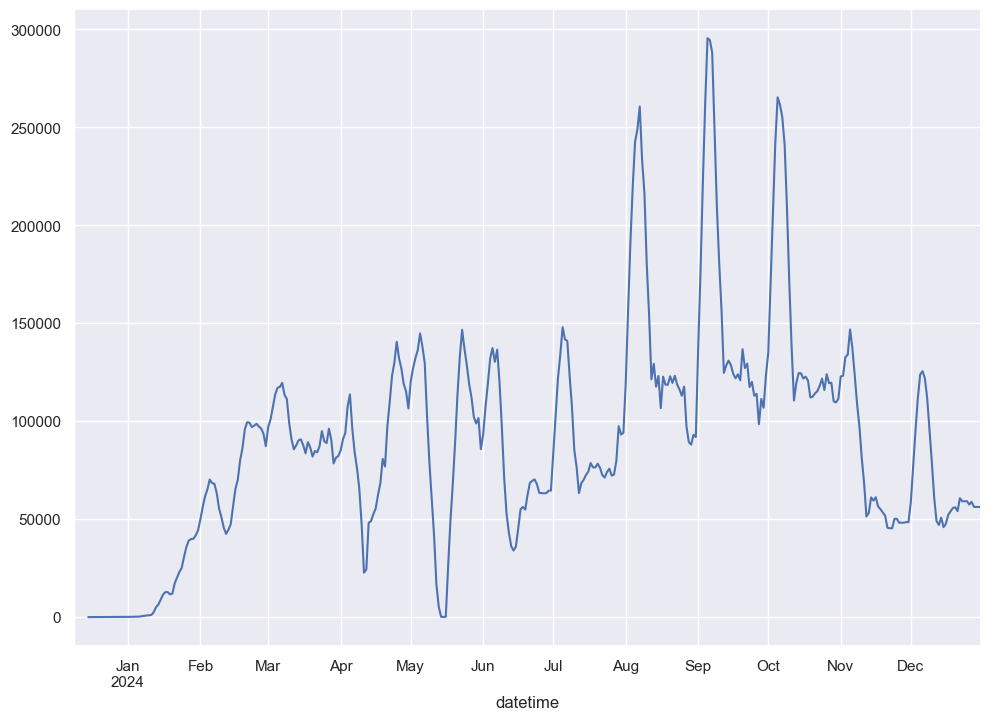

In [72]:
df['consumption'].resample('D').sum().rolling(7).mean().plot()

<Axes: xlabel='datetime'>

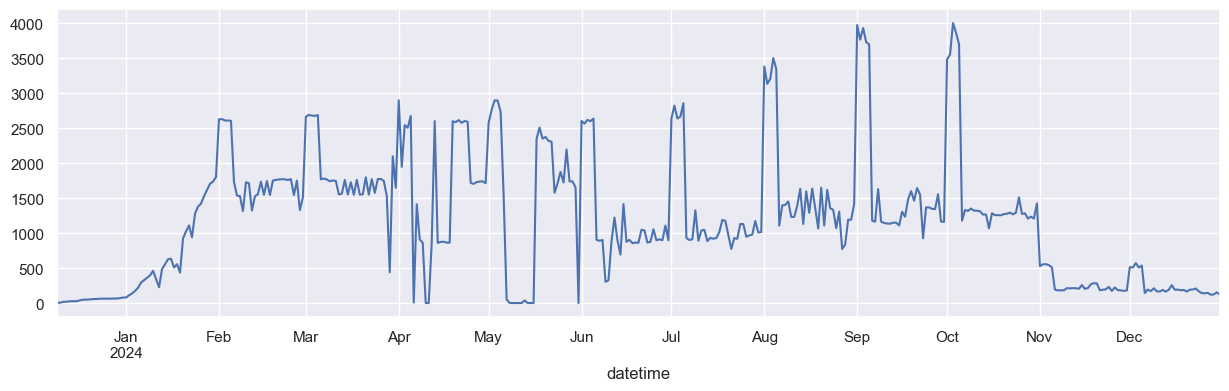

In [73]:
df.resample('D').size().plot(figsize=(15,4))

<Axes: xlabel='month'>

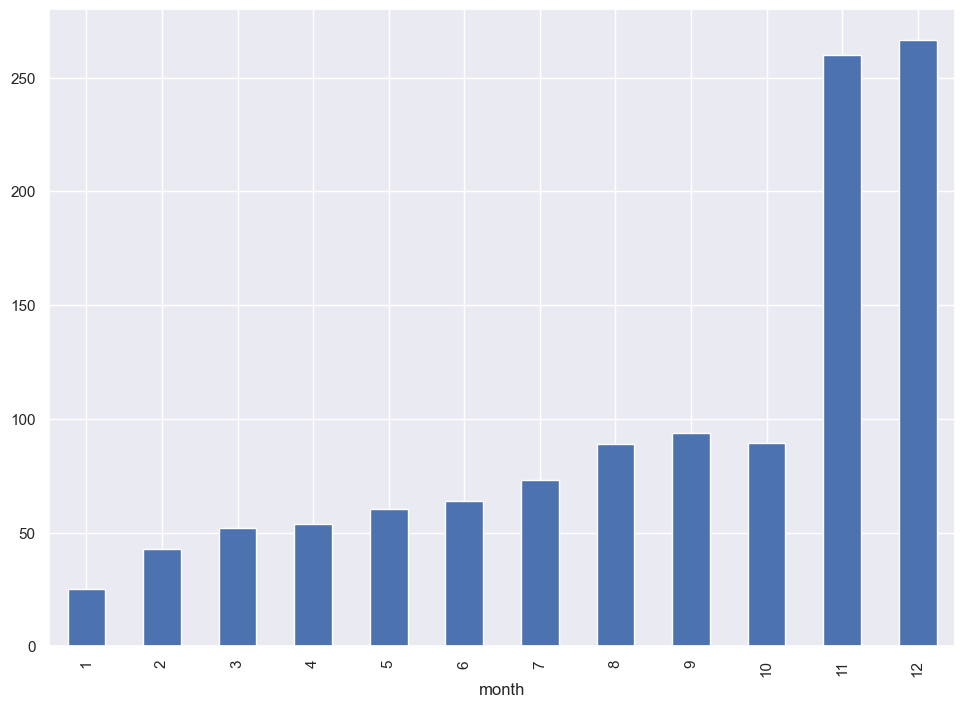

In [74]:
df.groupby('month')['consumption'].mean().plot(kind='bar')

<Axes: xlabel='datetime'>

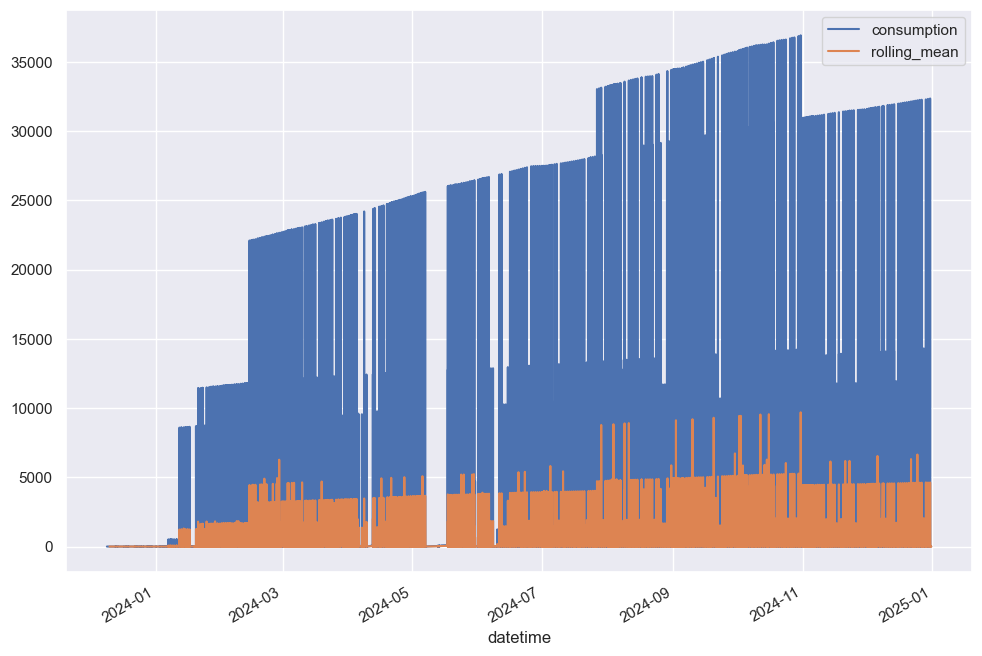

In [75]:
df['rolling_mean'] = df['consumption'].rolling(window=7).mean()

df[['consumption', 'rolling_mean']].plot()

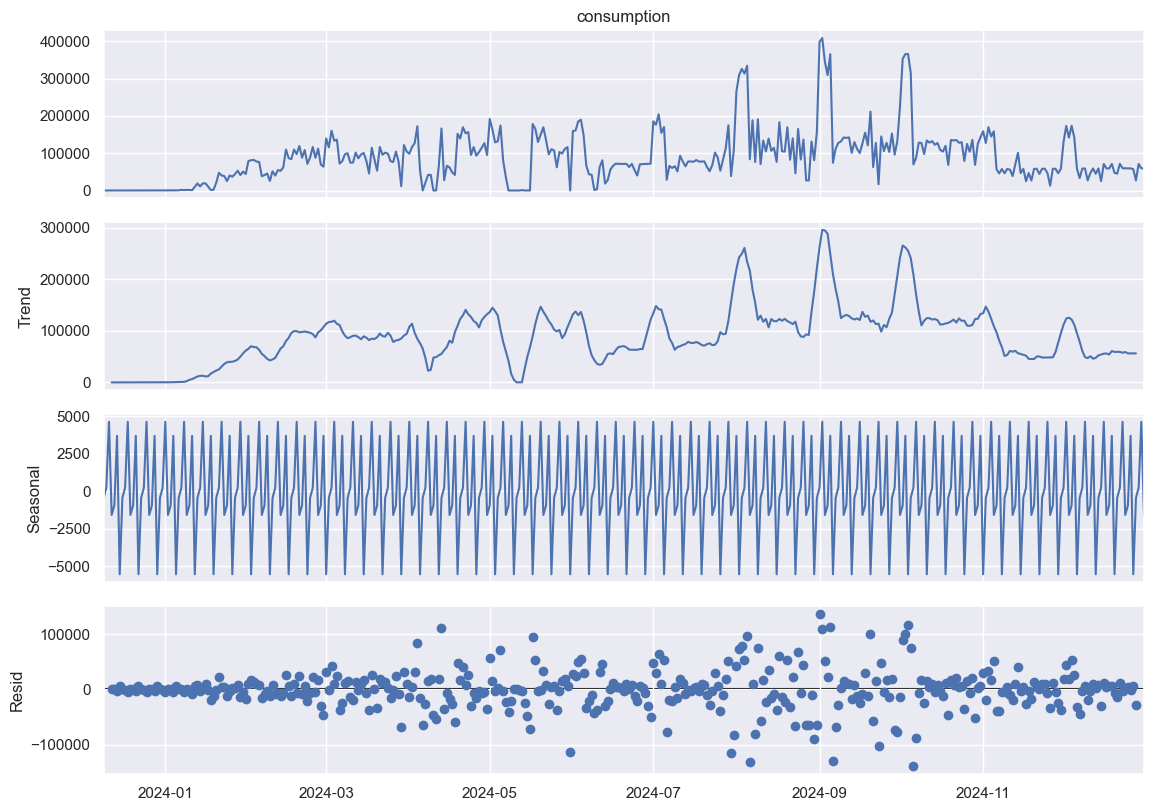

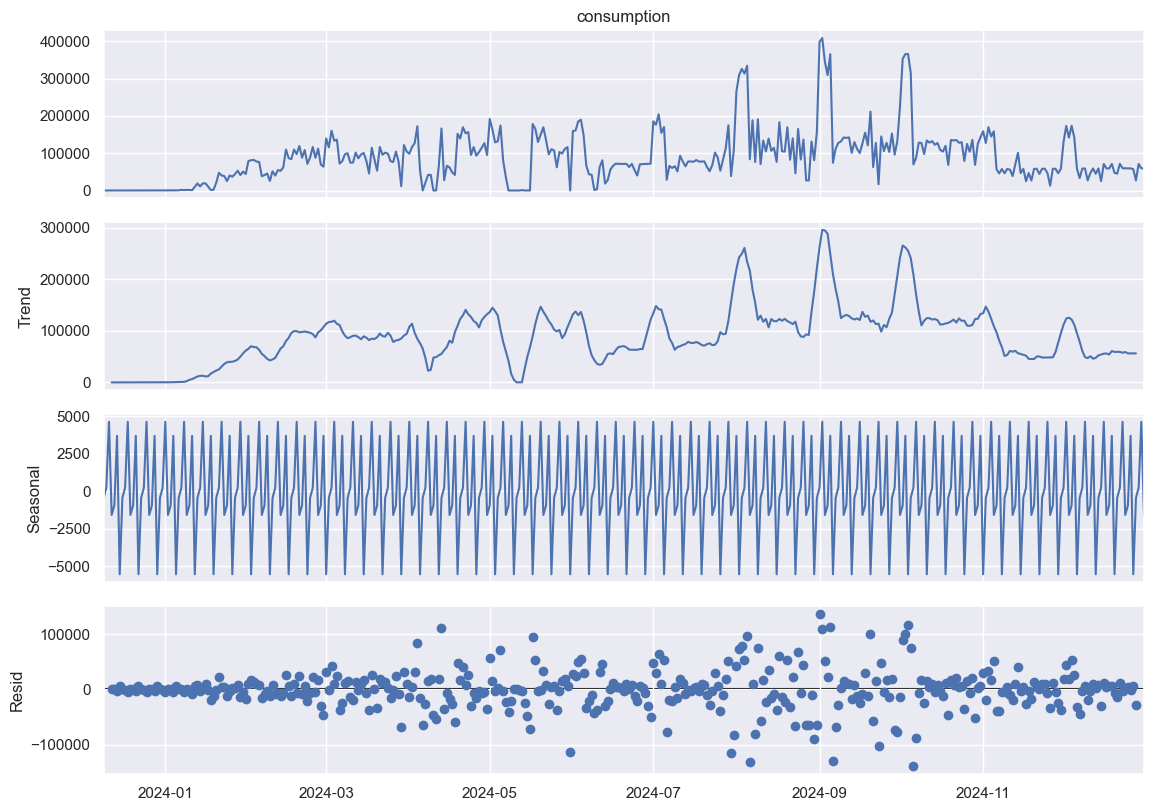

In [76]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['consumption'].resample('D').sum(), model='additive')
result.plot()

<Axes: xlabel='household_ID'>

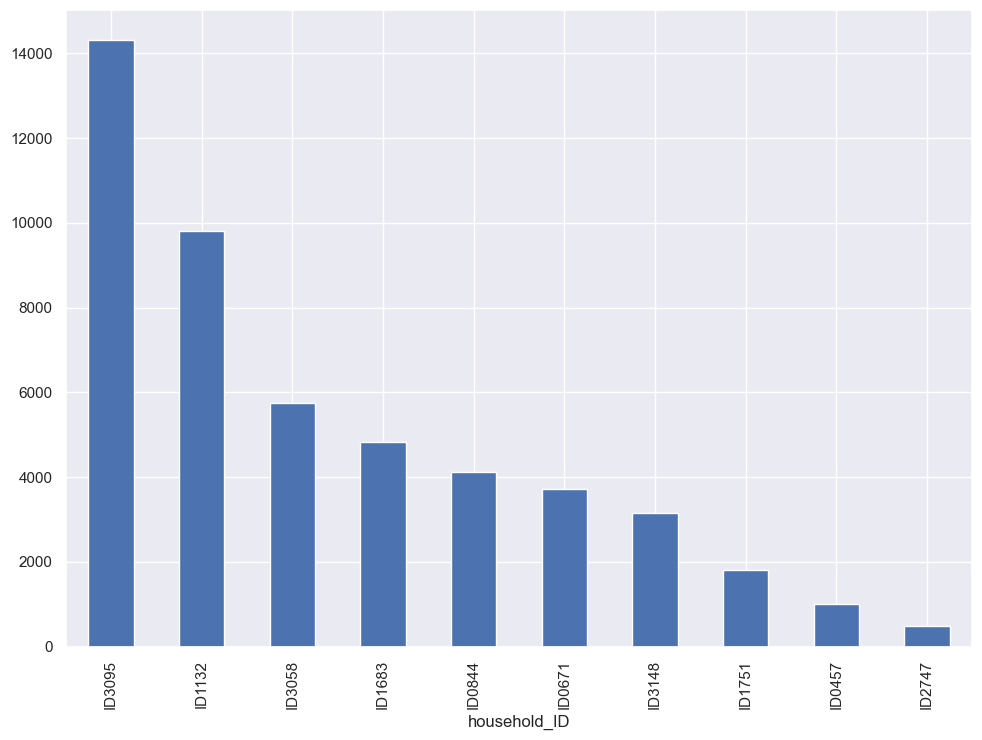

In [77]:
df.groupby('household_ID')['consumption'].mean().sort_values(ascending=False).head(10).plot(kind='bar')

<Axes: xlabel='datetime'>

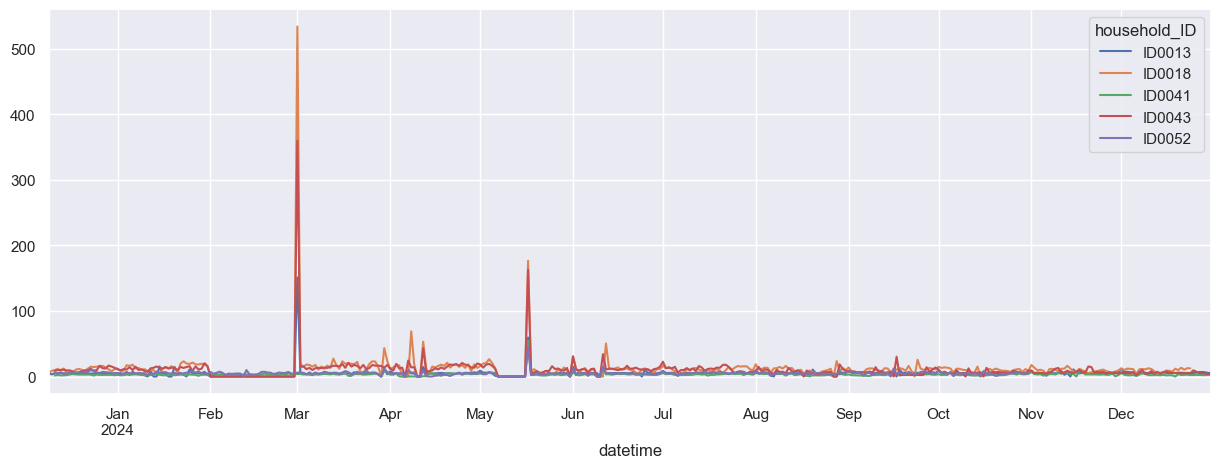

In [78]:
df.groupby('household_ID')['consumption'].resample('D').sum().unstack(0).iloc[:, :5].plot(figsize=(15,5))

<Axes: xlabel='day_of_week', ylabel='hour'>

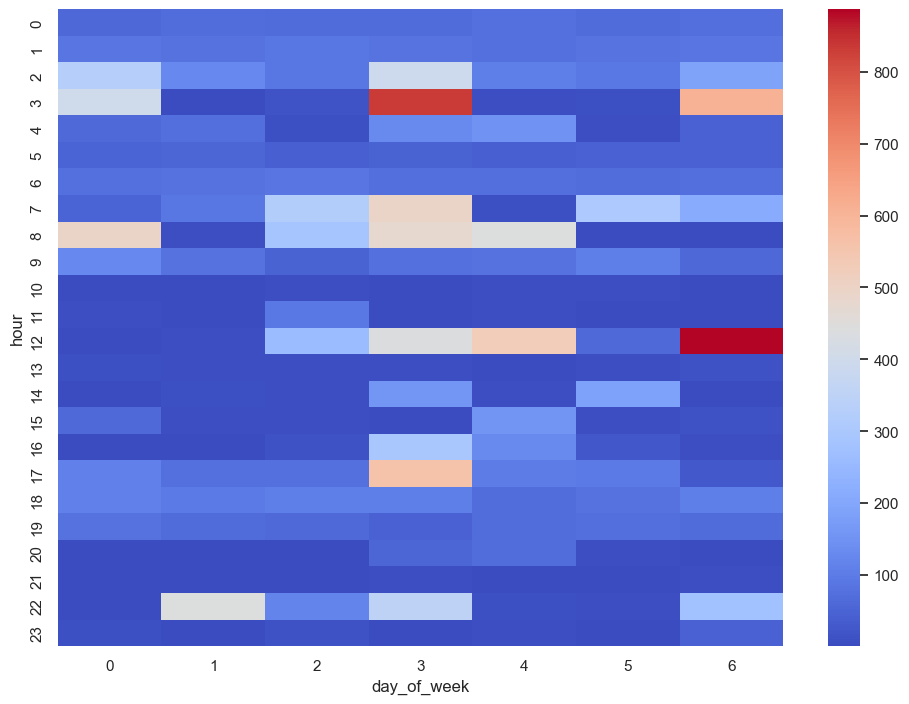

In [79]:
pivot = df.pivot_table(values='consumption',index='hour', columns='day_of_week', aggfunc='mean')

sns.heatmap(pivot, cmap='coolwarm')